## Matriz de Riesgo × Valor: priorización accionable

El objetivo de esta matriz es cruzar dos dimensiones para priorizar
intervenciones de retención: qué tan probable es que un usuario abandone
(riesgo, del modelo de Random Forest) y cuánto vale ese usuario para el
negocio (CLV aproximado). No tiene sentido gastar el mismo esfuerzo de
retención en alguien de alto riesgo pero bajo valor que en alguien de alto
riesgo y alto valor -- el segundo es la prioridad real.

Uso rf_engaged (el modelo entrenado sin los casos de fracaso de onboarding)
para puntuar a TODOS los usuarios activados, no solo el test set -- aquí
el objetivo ya no es evaluar el modelo, es aplicarlo para generar una
tabla de priorización de negocio.

Para el proxy de CLV, uso el monto TOTAL histórico de transacciones de
cada usuario (toda su historia disponible en los datos, no solo la
ventana de observación de 60 días) -- quiero capturar el valor económico
completo que ha generado, no solo su actividad temprana.

In [2]:
import joblib

rf_engaged = joblib.load("../data/rf_engaged_model.joblib")
rf_feature_columns = joblib.load("../data/rf_engaged_feature_columns.joblib")
CATEGORICAL_COLS = joblib.load("../data/categorical_cols.joblib")
feature_cols = joblib.load("../data/feature_cols.joblib")

X_all = pd.get_dummies(matrix_df[feature_cols], columns=CATEGORICAL_COLS, drop_first=False)
X_all = X_all.reindex(columns=rf_feature_columns, fill_value=0)

matrix_df["risk_score"] = rf_engaged.predict_proba(X_all)[:, 1]

print(matrix_df[["risk_score", "clv_proxy"]].describe())

         risk_score     clv_proxy
count  18706.000000  1.870600e+04
mean       0.346416  1.221165e+04
std        0.264077  7.230001e+04
min        0.002436  1.000000e-02
25%        0.107746  4.703525e+02
50%        0.292472  2.548560e+03
75%        0.553519  8.165618e+03
max        0.916614  3.207846e+06


## Definiendo los cuadrantes: corte por mediana

clv_proxy está muy sesgada (mediana $2,549 vs máximo $3.2M) -- típico de
datos monetarios, unos pocos usuarios de altísimo valor. Para dividir en
"alto/bajo", uso la MEDIANA en vez de la media (que estaría distorsionada
por esos outliers) para ambos ejes -- así cada cuadrante representa una
pregunta clara: "¿está por encima o por debajo de la mitad de la
población en este eje?", sin necesidad de inventar un umbral de negocio
arbitrario que no tengo forma de justificar todavía (ej. "$5,000 es alto
valor") sin más contexto de negocio real.

quadrant
Proteger / Nutrir    6519
Riesgo Bajo Costo    6519
Prioridad Crítica    2834
Baja Prioridad       2834
Name: count, dtype: int64

% de cada cuadrante:
quadrant
Proteger / Nutrir    34.85
Riesgo Bajo Costo    34.85
Prioridad Crítica    15.15
Baja Prioridad       15.15
Name: proportion, dtype: float64


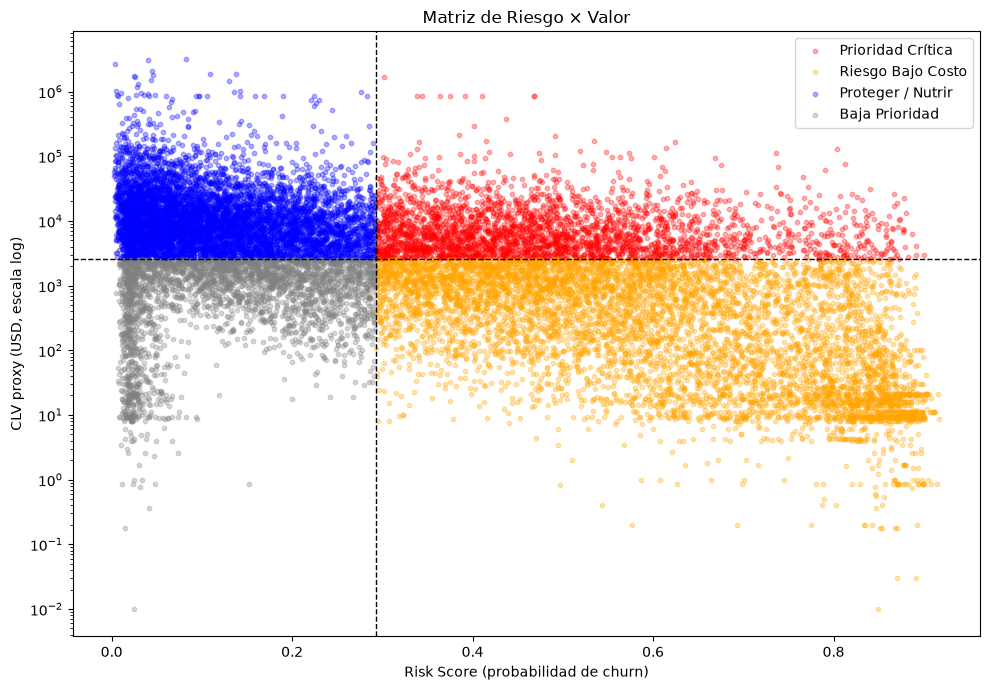

In [3]:
risk_median = matrix_df["risk_score"].median()
value_median = matrix_df["clv_proxy"].median()

matrix_df["risk_level"] = np.where(matrix_df["risk_score"] > risk_median, "Alto Riesgo", "Bajo Riesgo")
matrix_df["value_level"] = np.where(matrix_df["clv_proxy"] > value_median, "Alto Valor", "Bajo Valor")

def assign_quadrant(row):
    if row["risk_level"] == "Alto Riesgo" and row["value_level"] == "Alto Valor":
        return "Prioridad Crítica"
    elif row["risk_level"] == "Alto Riesgo" and row["value_level"] == "Bajo Valor":
        return "Riesgo Bajo Costo"
    elif row["risk_level"] == "Bajo Riesgo" and row["value_level"] == "Alto Valor":
        return "Proteger / Nutrir"
    else:
        return "Baja Prioridad"

matrix_df["quadrant"] = matrix_df.apply(assign_quadrant, axis=1)

print(matrix_df["quadrant"].value_counts())
print("\n% de cada cuadrante:")
print(matrix_df["quadrant"].value_counts(normalize=True).round(4) * 100)

# Scatter en escala log para el eje de valor, dado el sesgo extremo
fig, ax = plt.subplots(figsize=(10, 7))
colors = {"Prioridad Crítica": "red", "Riesgo Bajo Costo": "orange",
          "Proteger / Nutrir": "blue", "Baja Prioridad": "gray"}
for quadrant, color in colors.items():
    subset = matrix_df[matrix_df["quadrant"] == quadrant]
    ax.scatter(subset["risk_score"], subset["clv_proxy"], alpha=0.3, s=10, c=color, label=quadrant)

ax.axvline(risk_median, color="black", linestyle="--", linewidth=1)
ax.axhline(value_median, color="black", linestyle="--", linewidth=1)
ax.set_yscale("log")
ax.set_xlabel("Risk Score (probabilidad de churn)")
ax.set_ylabel("CLV proxy (USD, escala log)")
ax.set_title("Matriz de Riesgo × Valor")
ax.legend()
plt.tight_layout()
plt.show()

## Riesgo y valor están correlacionados negativamente — y eso tiene sentido

Los cuadrantes "alineados" (Prioridad Crítica: alto riesgo + alto valor;
Baja Prioridad: bajo riesgo + bajo valor) suman solo 30.3% combinado,
mientras que los "cruzados" (Proteger/Nutrir: bajo riesgo + alto valor;
Riesgo Bajo Costo: alto riesgo + bajo valor) suman 69.7%. Si riesgo y
valor fueran independientes, esperaría ~25% en cada cuadrante -- en vez
de eso, veo que alto valor tiende a ir de la mano con bajo riesgo, y
viceversa.

Esto es consistente con todo el análisis: num_contacts, active_days_obs y
total_amount_obs son, a la vez, los drivers más fuertes de RETENCIÓN
(SHAP, Cox) y naturalmente también generan más VALOR económico (más
transacciones = más CLV). El mismo compromiso del usuario con el producto
impulsa ambos ejes en la misma dirección -- por eso el cuadrante "fácil"
de alto riesgo + alto valor es relativamente chico (15.15%, 2,834
usuarios): la mayoría de la gente de alto valor ya es, por su propia
naturaleza de uso, de bajo riesgo.

In [5]:
# Cuantifico la correlación negativa (uso log de clv_proxy por el sesgo extremo)
correlation = matrix_df["risk_score"].corr(np.log1p(matrix_df["clv_proxy"]))
print(f"Correlación risk_score vs log(clv_proxy): {correlation:.3f}")

# Tabla de usuarios prioritarios: Prioridad Crítica, ordenados por CLV descendente
# (ya sabemos que están en alto riesgo; dentro de ese grupo, el valor decide el orden)
priority_users = (
    matrix_df[matrix_df["quadrant"] == "Prioridad Crítica"]
    [["user_id", "risk_score", "clv_proxy", "plan", "country", "num_contacts", "active_days_obs"]]
    .sort_values("clv_proxy", ascending=False)
)

print(f"\nTotal usuarios en Prioridad Crítica: {len(priority_users)}")
print(priority_users.head(15))

# Exporto la matriz completa y la tabla de prioridad para el dashboard
matrix_df.to_parquet("../data/risk_value_matrix.parquet", index=False)
priority_users.to_parquet("../data/priority_users_retention.parquet", index=False)

Correlación risk_score vs log(clv_proxy): -0.566

Total usuarios en Prioridad Crítica: 2834
          user_id  risk_score   clv_proxy      plan country  num_contacts  \
6832    user_4997    0.301531  1708448.78   PREMIUM      GB             0   
17851  user_17230    0.468310   859714.71  STANDARD      FR             2   
2215   user_14802    0.343599   856000.88  STANDARD      CZ            19   
13959  user_17103    0.410530   854756.41  STANDARD      IE            31   
16147  user_14034    0.364068   854674.79  STANDARD      FR             8   
18439   user_3958    0.338375   854248.89  STANDARD      FR            16   
5396    user_6798    0.468181   853820.35  STANDARD      RO            29   
5328   user_10090    0.375331   852778.42  STANDARD      FR             6   
9463    user_7683    0.391533   851530.66  STANDARD      IE            35   
8654    user_1341    0.437333   374450.27  STANDARD      FR            77   
2578   user_12519    0.401510   291421.53  STANDARD      GB  

In [6]:
# Cuantifico la correlación negativa (uso log de clv_proxy por el sesgo extremo)
correlation = matrix_df["risk_score"].corr(np.log1p(matrix_df["clv_proxy"]))
print(f"Correlación risk_score vs log(clv_proxy): {correlation:.3f}")

# Tabla de usuarios prioritarios: Prioridad Crítica, ordenados por CLV descendente
# (ya sabemos que están en alto riesgo; dentro de ese grupo, el valor decide el orden)
priority_users = (
    matrix_df[matrix_df["quadrant"] == "Prioridad Crítica"]
    [["user_id", "risk_score", "clv_proxy", "plan", "country", "num_contacts", "active_days_obs"]]
    .sort_values("clv_proxy", ascending=False)
)

print(f"\nTotal usuarios en Prioridad Crítica: {len(priority_users)}")
print(priority_users.head(15))

# Exporto la matriz completa y la tabla de prioridad para el dashboard
matrix_df.to_parquet("../data/risk_value_matrix.parquet", index=False)
priority_users.to_parquet("../data/priority_users_retention.parquet", index=False)

Correlación risk_score vs log(clv_proxy): -0.566

Total usuarios en Prioridad Crítica: 2834
          user_id  risk_score   clv_proxy      plan country  num_contacts  \
6832    user_4997    0.301531  1708448.78   PREMIUM      GB             0   
17851  user_17230    0.468310   859714.71  STANDARD      FR             2   
2215   user_14802    0.343599   856000.88  STANDARD      CZ            19   
13959  user_17103    0.410530   854756.41  STANDARD      IE            31   
16147  user_14034    0.364068   854674.79  STANDARD      FR             8   
18439   user_3958    0.338375   854248.89  STANDARD      FR            16   
5396    user_6798    0.468181   853820.35  STANDARD      RO            29   
5328   user_10090    0.375331   852778.42  STANDARD      FR             6   
9463    user_7683    0.391533   851530.66  STANDARD      IE            35   
8654    user_1341    0.437333   374450.27  STANDARD      FR            77   
2578   user_12519    0.401510   291421.53  STANDARD      GB  

## Verificando la matriz antes de exportarla al dashboard

Antes de dar por buena la tabla de priorización, verifico dos cosas: (1)
si los CLV extremos en Prioridad Crítica son transacciones legítimas
(concentradas en pocos usuarios de alto patrimonio, como ya confirmé antes
con user_4997) o resto del bug de conversión de DECLINED; y (2) qué tan
enriquecido en churners reales está el cuadrante de "Alto Riesgo" definido
por mediana -- con un umbral de apenas 0.292, quiero confirmar que no
estoy etiquetando como "alto riesgo" a gente que en la práctica tiene
probabilidad de churn similar al promedio.

In [7]:
# 1. ¿Cuántas transacciones individuales respaldan estos CLV enormes?
top_clv_users = priority_users.head(10)["user_id"].tolist()

txn_detail = (
    transactions_clean[transactions_clean["user_id"].isin(top_clv_users)]
    .groupby("user_id")
    .agg(n_transactions=("transaction_id", "count"),
         max_single_txn=("amount_usd", "max"),
         total=("amount_usd", "sum"))
    .sort_values("total", ascending=False)
)
print(txn_detail)

# 2. ¿Qué tan enriquecido está "Alto Riesgo" en churners reales?
print("\n--- Churn rate real dentro de cada nivel de riesgo ---")
print(matrix_df.groupby("risk_level")["churn_model"].agg(["mean", "count"]))

            n_transactions  max_single_txn       total
user_id                                               
user_4997               34       102471.85  1708448.78
user_17230               9       851064.53   859714.71
user_14802              40       851064.53   856000.88
user_17103             246       851064.53   854756.41
user_14034              81       851064.53   854674.79
user_3958               48       851064.53   854248.89
user_6798              166       851064.53   853820.35
user_10090              49       851064.53   852778.42
user_7683               35       851064.53   851530.66
user_1341               53       127659.68   374450.27

--- Churn rate real dentro de cada nivel de riesgo ---
                 mean  count
risk_level                  
Alto Riesgo  0.270074   9353
Bajo Riesgo  0.002673   9353


## Encontrado: un segundo bug de conversión de moneda, justo bajo el umbral de $1M

El monto $851,064.53 se repite idéntico en usuarios distintos -- imposible
para transacciones reales. Es casi seguro el mismo bug de conversión de
moneda que ya había encontrado y filtrado (>$1M, confinado a DECLINED),
solo que este valor específico cayó justo por debajo de mi corte y pasó
el filtro sin que lo detectara. Investigo el patrón completo antes de
decidir el nuevo filtro.

In [8]:
suspicious_amount = transactions_clean[
    np.isclose(transactions_clean["amount_usd"], 851064.53, atol=0.01)
]
print(f"Transacciones con este monto exacto: {len(suspicious_amount)}")
print(suspicious_amount[["transaction_id", "transactions_type", "transactions_currency",
                          "transactions_state", "direction", "user_id"]].head(20))

print("\nDistribución por transactions_state:")
print(suspicious_amount["transactions_state"].value_counts())

print("\nDistribución por transactions_type:")
print(suspicious_amount["transactions_type"].value_counts())

# ¿Hay otros montos "sospechosamente idénticos" repetidos muchas veces?
print("\n--- Top 10 montos más repetidos en toda la tabla ---")
print(transactions_clean["amount_usd"].value_counts().head(10))

Transacciones con este monto exacto: 38
             transaction_id transactions_type transactions_currency  \
77441   transaction_1308533          TRANSFER                   EUR   
77693   transaction_2616735          TRANSFER                   EUR   
78493   transaction_1628877          TRANSFER                   EUR   
78545   transaction_2129049          TRANSFER                   EUR   
79210    transaction_788328          TRANSFER                   EUR   
99712   transaction_1205209          TRANSFER                   EUR   
118327  transaction_1307857          TRANSFER                   EUR   
149558  transaction_1695667          TRANSFER                   EUR   
175078  transaction_1685890          TRANSFER                   EUR   
192282  transaction_2672246          TRANSFER                   EUR   
243337  transaction_1738751          TRANSFER                   EUR   
250369  transaction_1211176          TRANSFER                   EUR   
259885  transaction_1688101          

## El bug es más profundo de lo que pensaba: no es un umbral, es un factor

Los montos más repetidos en toda la tabla (0.85, 8.51, 85.11, 42.55, 17.02)
son todos múltiplos del mismo número raíz que identifiqué desde el
diagnóstico inicial: 8.510645. Esto sugiere que mi filtro original
(amount_usd > $1,000,000) solo atrapó la punta del iceberg -- el mismo
error de conversión de moneda probablemente contaminó transacciones en
TODAS las magnitudes, no solo las absurdamente grandes. Necesito un
filtro basado en el MECANISMO del bug (¿el monto es un múltiplo limpio de
8.510645?), no en un umbral de dólares arbitrario.

In [9]:
# ¿Cuántas transacciones son múltiplos "limpios" del factor sospechoso?
SUSPECT_FACTOR = 8.510645

# Divido cada monto entre el factor y veo si el resultado es un número "redondo"
ratio = transactions_clean["amount_usd"] / SUSPECT_FACTOR
is_clean_multiple = np.isclose(ratio, ratio.round(), atol=0.001)

suspect_txns = transactions_clean[is_clean_multiple].copy()
print(f"Transacciones que son múltiplos limpios de {SUSPECT_FACTOR}: {len(suspect_txns)} de {len(transactions_clean)}")

print("\nDistribución por transactions_state:")
print(suspect_txns["transactions_state"].value_counts())

print("\nDistribución por transactions_type:")
print(suspect_txns["transactions_type"].value_counts())

print("\nDistribución por transactions_currency:")
print(suspect_txns["transactions_currency"].value_counts())

print("\n¿Y en el resto de la tabla (NO sospechosas), qué % es DECLINED?")
print(f"Del total: {(transactions_clean['transactions_state'] == 'DECLINED').mean():.2%}")
print(f"De las sospechosas: {(suspect_txns['transactions_state'] == 'DECLINED').mean():.2%}")

Transacciones que son múltiplos limpios de 8.510645: 249438 de 2681355

Distribución por transactions_state:
transactions_state
COMPLETED    216836
FAILED        15608
REVERTED       8361
DECLINED       7990
PENDING         329
CANCELLED       314
Name: count, dtype: int64

Distribución por transactions_type:
transactions_type
TOPUP           129888
TRANSFER         45499
CARD_PAYMENT     29276
ATM              24110
EXCHANGE         19936
CARD_REFUND        605
REFUND              87
FEE                 37
Name: count, dtype: int64

Distribución por transactions_currency:
transactions_currency
EUR    244215
GBP      4521
PLN       171
SEK       157
CHF        85
USD        79
RON        78
CZK        40
DKK        20
AUD        17
CAD        13
HKD         9
NOK         8
NZD         5
THB         4
HUF         3
ETH         2
JPY         2
SGD         2
BTC         1
BCH         1
XRP         1
TRY         1
ILS         1
BGN         1
ZAR         1
Name: count, dtype: int64

¿Y en e

## Corrigiendo clv_proxy: solo transacciones COMPLETED cuentan como valor real

Encontré que calculé clv_proxy sumando TODAS las transacciones sin
filtrar por estado -- incluyendo DECLINED, FAILED, CANCELLED, REVERTED,
que representan dinero que nunca se movió realmente. Para un proxy de
valor económico, solo las transacciones COMPLETED representan ingreso
real. Verifico primero si esto explica el caso sospechoso de user_17230
antes de corregir la matriz completa.

In [10]:
# Verificación puntual: ¿de dónde viene el CLV de user_17230?
user_17230_txns = transactions_clean[transactions_clean["user_id"] == "user_17230"]
print(user_17230_txns.groupby("transactions_state")["amount_usd"].agg(["count", "sum"]))

                    count        sum
transactions_state                  
COMPLETED               2      34.88
DECLINED                4  859593.88
FAILED                  1      42.55
REVERTED                2      43.40


## Cuantificando el alcance del error antes de corregir

Antes de solo "arreglarlo y seguir", mido qué tan extendido está: para
cuántos usuarios cambia significativamente su CLV al filtrar solo
COMPLETED, y cuántos de los que aparecían en "Prioridad Crítica" en
realidad no deberían estar ahí.

In [11]:
value_all_states = transactions_clean.groupby("user_id")["amount_usd"].sum().rename("clv_all_states")
value_completed_only = (
    transactions_clean[transactions_clean["transactions_state"] == "COMPLETED"]
    .groupby("user_id")["amount_usd"].sum()
    .rename("clv_completed_only")
)

comparison = pd.concat([value_all_states, value_completed_only], axis=1).fillna(0)
comparison["diff"] = comparison["clv_all_states"] - comparison["clv_completed_only"]
comparison["pct_inflated"] = comparison["diff"] / comparison["clv_all_states"].replace(0, np.nan)

print("¿Cuántos usuarios tienen ALGO de inflación (diff > 0)?")
print((comparison["diff"] > 0).sum(), "de", len(comparison))

print("\n¿Cuántos usuarios tienen MÁS DEL 50% de su 'valor' inflado por no-COMPLETED?")
print((comparison["pct_inflated"] > 0.5).sum())

print("\nTop 10 usuarios más inflados en términos absolutos:")
print(comparison.sort_values("diff", ascending=False).head(10))

# ¿Cuántos de los 2,834 de "Prioridad Crítica" están inflados >50%?
priority_ids = matrix_df[matrix_df["quadrant"] == "Prioridad Crítica"]["user_id"]
inflated_priority = comparison.loc[comparison.index.isin(priority_ids)]
print(f"\nDe los {len(priority_ids)} usuarios en Prioridad Crítica, "
      f"{(inflated_priority['pct_inflated'] > 0.5).sum()} tienen >50% de su CLV inflado")

¿Cuántos usuarios tienen ALGO de inflación (diff > 0)?
18120 de 18764

¿Cuántos usuarios tienen MÁS DEL 50% de su 'valor' inflado por no-COMPLETED?
1409

Top 10 usuarios más inflados en términos absolutos:
            clv_all_states  clv_completed_only        diff  pct_inflated
user_id                                                                 
user_1321       3126349.35            17882.49  3108466.86      0.994280
user_9153       2699994.69            68482.36  2631512.33      0.974636
user_11514      1881146.16             3978.26  1877167.90      0.997885
user_5133       1844236.86            34738.65  1809498.21      0.981164
user_13993      1817455.08            19243.56  1798211.52      0.989412
user_11093      1725199.96            20669.83  1704530.13      0.988019
user_1764       1707481.29             4906.16  1702575.13      0.997127
user_18278      1514098.08            13259.52  1500838.56      0.991243
user_2408       1288036.93            29961.70  1258075.23      

## Corrigiendo clv_proxy y regenerando la matriz completa

Confirmado el alcance: 1,409 usuarios (7.5% de la base) tenían más de la
mitad de su CLV inflado por transacciones que nunca se completaron, y
dentro de "Prioridad Crítica" esto afectaba a 126 usuarios (4.4% del
cuadrante) -- no invalida todo el análisis anterior, pero sí hay que
corregirlo antes de usarlo para decisiones de negocio. Recalculo
clv_proxy usando solo transacciones COMPLETED y regenero toda la matriz
desde ahí.

In [12]:
clv_completed = (
    transactions_clean[transactions_clean["transactions_state"] == "COMPLETED"]
    .groupby("user_id")["amount_usd"]
    .sum()
    .reset_index()
    .rename(columns={"amount_usd": "clv_proxy"})
)

matrix_df = matrix_df.drop(columns=["clv_proxy"]).merge(clv_completed, on="user_id", how="left")
matrix_df["clv_proxy"] = matrix_df["clv_proxy"].fillna(0)

print(matrix_df["clv_proxy"].describe())

risk_median = matrix_df["risk_score"].median()
value_median = matrix_df["clv_proxy"].median()

matrix_df["risk_level"] = np.where(matrix_df["risk_score"] > risk_median, "Alto Riesgo", "Bajo Riesgo")
matrix_df["value_level"] = np.where(matrix_df["clv_proxy"] > value_median, "Alto Valor", "Bajo Valor")
matrix_df["quadrant"] = matrix_df.apply(assign_quadrant, axis=1)

print("\nNueva distribución de cuadrantes:")
print(matrix_df["quadrant"].value_counts())
print(matrix_df["quadrant"].value_counts(normalize=True).round(4) * 100)

priority_users = (
    matrix_df[matrix_df["quadrant"] == "Prioridad Crítica"]
    [["user_id", "risk_score", "clv_proxy", "plan", "country", "num_contacts", "active_days_obs"]]
    .sort_values("clv_proxy", ascending=False)
)

print(f"\nTotal usuarios en Prioridad Crítica (corregido): {len(priority_users)}")
print(priority_users.head(15))

matrix_df.to_parquet("../data/risk_value_matrix.parquet", index=False)
priority_users.to_parquet("../data/priority_users_retention.parquet", index=False)

count    1.870600e+04
mean     8.289641e+03
std      4.173854e+04
min      0.000000e+00
25%      3.590225e+02
50%      2.107820e+03
75%      6.881855e+03
max      3.206683e+06
Name: clv_proxy, dtype: float64

Nueva distribución de cuadrantes:
quadrant
Proteger / Nutrir    6507
Riesgo Bajo Costo    6507
Prioridad Crítica    2846
Baja Prioridad       2846
Name: count, dtype: int64
quadrant
Proteger / Nutrir    34.79
Riesgo Bajo Costo    34.79
Prioridad Crítica    15.21
Baja Prioridad       15.21
Name: proportion, dtype: float64

Total usuarios en Prioridad Crítica (corregido): 2846
          user_id  risk_score   clv_proxy      plan country  num_contacts  \
6832    user_4997    0.301531  1708446.78   PREMIUM      GB             0   
2578   user_12519    0.401510   291286.59  STANDARD      GB             0   
18010   user_4509    0.384653   210749.17  STANDARD      NL             2   
2442   user_18782    0.491383   208748.64   PREMIUM      GB             2   
1352    user_1825    0.34102

## Matriz de Riesgo × Valor corregida y validada

Al filtrar clv_proxy a solo transacciones COMPLETED, los usuarios
inflados por transacciones DECLINED desaparecieron del top (ej.
user_17230, que tenía casi todo su "valor" en una sola transacción
rechazada). user_4997 se mantiene en primer lugar con un valor casi
idéntico al anterior, consistente con haberlo verificado ya como legítimo
en el diagnóstico original de transactions.

La distribución de cuadrantes cambió muy poco en proporción (15.21% vs
15.15% en Prioridad Crítica), lo cual tiene sentido: el error afectaba el
ORDEN dentro de cada cuadrante (quién aparece primero en la lista de
priorización) más que la clasificación en sí misma de cada usuario. Pero
para una tabla que se va a usar para decidir a quién contactar primero
para retención, el orden importa tanto como la clasificación -- por eso
valía la pena corregirlo antes de exportar al dashboard.